# **SolarPowerGeneration Regression Model Training and Evaluation**

This notebook impliments build, train, evaluate, and compare multiple machine-learning regression models to predict solarpowergeneration based on ●distance_to_solar_noon
●temperature  ●wind_speed ●sky_cover ●visibility ●humidity ●average_wind_speed ●average_pressure



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor


# Advanced ensemble models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


print("All libraries imported successfully")

All libraries imported successfully


In [3]:
#load the cleaned dataset 
df = pd.read_csv('solarpowergeneration.csv')
print(f"Data loaded: {df.shape}")
print(f"Columns: {df.shape[1]}")
print(f"Rows: {df.shape[0]}")
df.head()

Data loaded: (2920, 10)
Columns: 10
Rows: 2920


,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069


In [4]:
print("\nData Types:")
print(df.dtypes)


Data Types:
distance-to-solar-noon         float64
temperature                      int64
wind-direction                   int64
wind-speed                     float64
sky-cover                        int64
visibility                     float64
humidity                         int64
average-wind-speed-(period)    float64
average-pressure-(period)      float64
power-generated                  int64
dtype: object


In [5]:
df_filled = df.copy()
df_filled.fillna(df_filled.median(), inplace=True)
df= df_filled
df.isnull().sum()

distance-to-solar-noon         0
temperature                    0
wind-direction                 0
wind-speed                     0
sky-cover                      0
visibility                     0
humidity                       0
average-wind-speed-(period)    0
average-pressure-(period)      0
power-generated                0
dtype: int64

In [6]:
print(f"Data loaded: {df.shape}")
print(f"Columns: {df.shape[1]}")
print(f"Rows: {df.shape[0]}")
df.head()

Data loaded: (2920, 10)
Columns: 10
Rows: 2920


,distance-to-solar-noon,temperature,wind-direction,wind-speed,sky-cover,visibility,humidity,average-wind-speed-(period),average-pressure-(period),power-generated
0,0.859897,69,28,7.5,0,10.0,75,8.0,29.82,0
1,0.628535,69,28,7.5,0,10.0,77,5.0,29.85,0
2,0.397172,69,28,7.5,0,10.0,70,0.0,29.89,5418
3,0.165810,69,28,7.5,0,10.0,33,0.0,29.91,25477
4,0.065553,69,28,7.5,0,10.0,21,3.0,29.89,30069


In [7]:
# Check data types and missing values
print("\nData Info:")
print(f"Missing values: {df.isna().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"\nData types:")
print(df.dtypes.value_counts())


Data Info:
Missing values: 0
Duplicate rows: 0

Data types:
float64    5
int64      5
Name: count, dtype: int64


In [8]:
# Split the data into features (X) and target (y)
X = df.drop("power-generated", axis=1) 
y = df["power-generated"] 

print("Feature and target created:\n")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nNumber of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")

Feature and target created:

X shape: (2920, 9)
y shape: (2920,)

Number of features: 9
Number of samples: 2920


In [9]:
# Display feature columns
print("\nFeature Columns:")
print("-"*20)
for i, col in enumerate(X.columns, 1):
    print(f"{i:2d}. {col}")


Feature Columns:
--------------------
 1. distance-to-solar-noon
 2. temperature
 3. wind-direction
 4. wind-speed
 5. sky-cover
 6. visibility
 7. humidity
 8. average-wind-speed-(period)
 9. average-pressure-(period)


In [10]:
# Check target distribution
print("\nTarget Distribution:")
print("-"*20)
print(y.describe())

print("\nAdditional statistics:")
print(f"Minimum value: {y.min()}")
print(f"Maximum value: {y.max()}")
print(f"Mean value: {y.mean():.2f}")
print(f"Median value: {y.median():.2f}")
print(f"Standard Deviation: {y.std():.2f}")


Target Distribution:
--------------------
count     2920.000000
mean      6979.846233
std      10312.336413
min          0.000000
25%          0.000000
50%        404.000000
75%      12723.500000
max      36580.000000
Name: power-generated, dtype: float64

Additional statistics:
Minimum value: 0
Maximum value: 36580
Mean value: 6979.85
Median value: 404.00
Standard Deviation: 10312.34


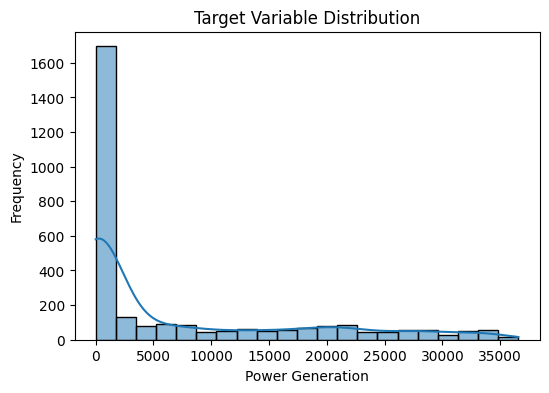

In [11]:
plt.figure(figsize=(6,4))
sns.histplot(df.iloc[:, -1], kde=True)
plt.title("Target Variable Distribution")
plt.xlabel("Power Generation")
plt.ylabel("Frequency")
plt.show()

### **Train-Test Split**

**Split data into training and testing sets**

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

print("Data Split Summary:")
print("-"*40)
print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"\nTraining target distribution:")
print(y_train.value_counts())
print(f"\nTest target distribution:")
print(y_test.value_counts())

Data Split Summary:
----------------------------------------
Training set size: 2336 samples (80.0%)
Test set size: 584 samples (20.0%)

Training features shape: (2336, 9)
Test features shape: (584, 9)

Training target distribution:
power-generated
0        1057
3           3
738         3
13489       2
345         2
         ... 
28930       1
381         1
1425        1
12017       1
25211       1
Name: count, Length: 1232, dtype: int64

Test target distribution:
power-generated
0        263
22350      2
2016       2
523        2
21804      2
        ... 
32087      1
1110       1
13686      1
3359       1
2065       1
Name: count, Length: 316, dtype: int64


**Define Machine Learning Models**

In [13]:
models = {
    "Multiple Linear Regression": LinearRegression(),
    
    "Ridge Regression": Ridge(alpha=1.0),
    
    "Lasso Regression": Lasso(alpha=0.01, max_iter=5000),
    
    "Decision Tree Regression": DecisionTreeRegressor(
        max_depth=6, random_state=42
    ),
    
    "XGBoost Regressor": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ),
    
    "LightGBM Regressor": LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    )
}


**Model Training**

In [31]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

model_results = {}

print("Model Performance (Regression)\n")

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # ===============================
    # Regression Metrics
    # ===============================

    # R2 Score
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # RMSE
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    # MAE
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    # Store test R2 score
    model_results[name] = test_r2

    # ===============================
    # Output
    # ===============================

    print(f"\n{name}")
    print(f"   Training R² Score : {train_r2:.4f}")
    print(f"   Testing  R² Score : {test_r2:.4f}")

    print(f"   Training MSE      : {train_mse:.4f}")
    print(f"   Testing  MSE      : {test_mse:.4f}")

    print(f"   Training RMSE     : {train_rmse:.4f}")
    print(f"   Testing  RMSE     : {test_rmse:.4f}")

    print(f"   Training MAE      : {train_mae:.4f}")
    print(f"   Testing  MAE      : {test_mae:.4f}")

    print("-" * 50)


Model Performance (Regression)


Multiple Linear Regression
   Training R² Score : 0.6547
   Testing  R² Score : 0.6251
   Training MSE      : 36787203.9904
   Testing  MSE      : 39494935.3044
   Training RMSE     : 6065.2456
   Testing  RMSE     : 6284.4996
   Training MAE      : 4891.7308
   Testing  MAE      : 4981.1543
--------------------------------------------------

Ridge Regression
   Training R² Score : 0.6547
   Testing  R² Score : 0.6248
   Training MSE      : 36788556.4606
   Testing  MSE      : 39520443.6743
   Training RMSE     : 6065.3571
   Testing  RMSE     : 6286.5287
   Training MAE      : 4888.4163
   Testing  MAE      : 4978.7172
--------------------------------------------------

Lasso Regression
   Training R² Score : 0.6547
   Testing  R² Score : 0.6251
   Training MSE      : 36787203.9989
   Testing  MSE      : 39495017.0555
   Training RMSE     : 6065.2456
   Testing  RMSE     : 6284.5061
   Training MAE      : 4891.7286
   Testing  MAE      : 4981.1586
----

In [32]:
# Predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# R2 Score
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# MSE
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# RMSE
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

# MAE
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"\n{name}")
print(f"Training R² Score : {train_r2:.4f}")
print(f"Testing  R² Score : {test_r2:.4f}")
print(f"Training MSE      : {train_mse:.4f}")
print(f"Testing  MSE      : {test_mse:.4f}")
print(f"Training RMSE     : {train_rmse:.4f}")
print(f"Testing  RMSE     : {test_rmse:.4f}")
print(f"Training MAE      : {train_mae:.4f}")
print(f"Testing  MAE      : {test_mae:.4f}")



LightGBM Regressor
Training R² Score : 0.9808
Testing  R² Score : 0.8920
Training MSE      : 2049075.2904
Testing  MSE      : 11378711.6053
Training RMSE     : 1431.4591
Testing  RMSE     : 3373.2346
Training MAE      : 745.2073
Testing  MAE      : 1624.8409


In [29]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data Split Summary:")
print("-"*40)
print(f"Training set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nTraining features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

print("\nTraining target statistics:")
print(y_train.describe())

print("\nTest target statistics:")
print(y_test.describe())


Data Split Summary:
----------------------------------------
Training set size: 2336 samples (80.0%)
Test set size: 584 samples (20.0%)

Training features shape: (2336, 9)
Test features shape: (584, 9)

Training target statistics:
count     2336.000000
mean      7003.485445
std      10324.407377
min          0.000000
25%          0.000000
50%        397.000000
75%      12818.500000
max      36368.000000
Name: power-generated, dtype: float64

Test target statistics:
count      584.000000
mean      6885.289384
std      10272.185368
min          0.000000
25%          0.000000
50%        443.000000
75%      11065.750000
max      36580.000000
Name: power-generated, dtype: float64


Actual vs Predicted Plots for All Regression Models

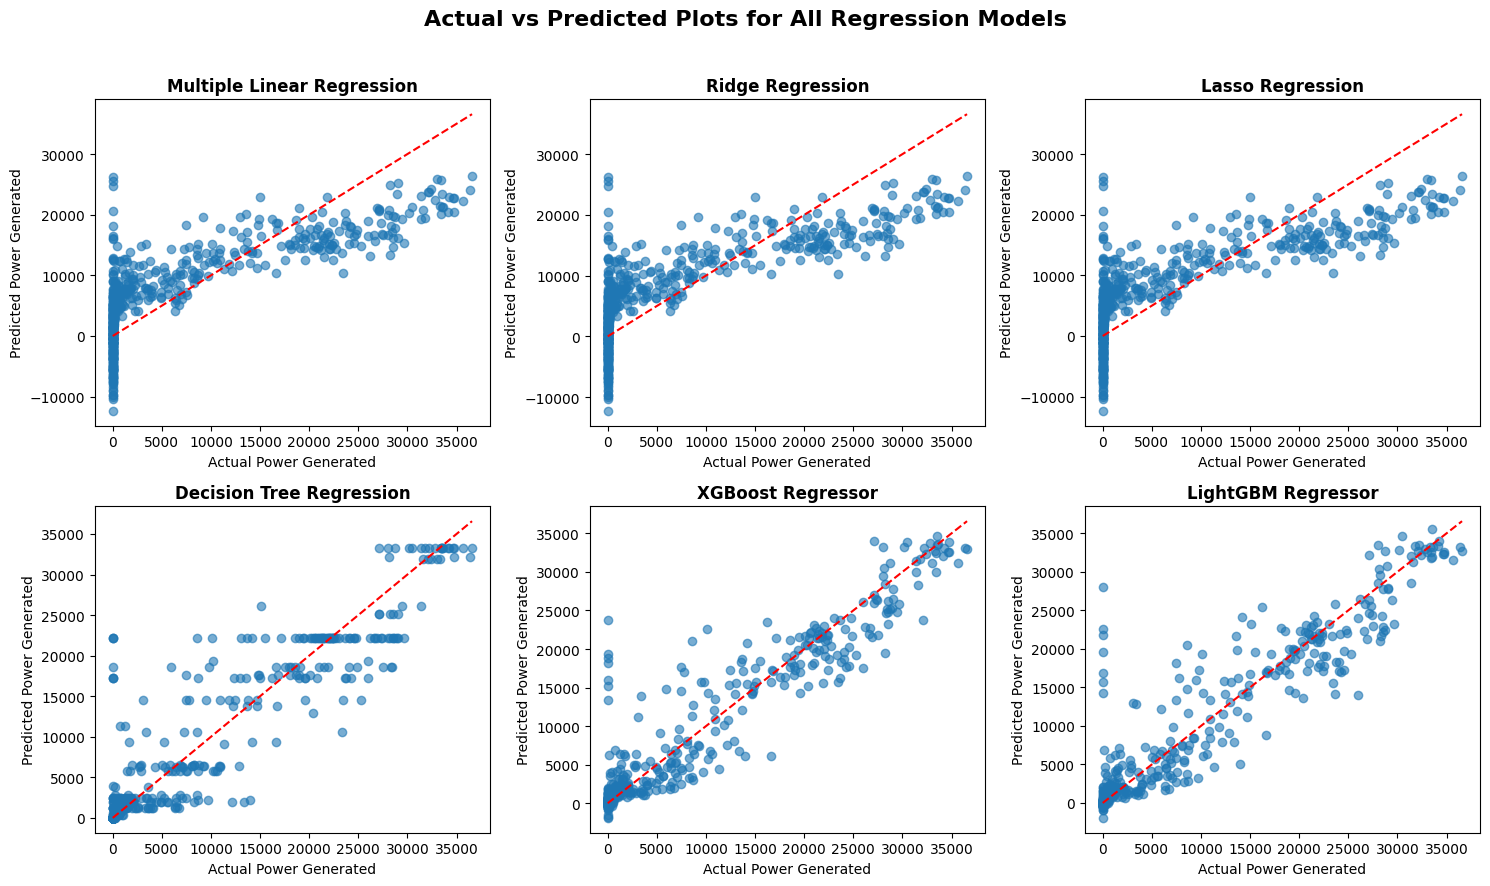

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)

    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6)
    
    # Perfect prediction line
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--')
    
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel("Actual Power Generated")
    ax.set_ylabel("Predicted Power Generated")

plt.suptitle(
    "Actual vs Predicted Plots for All Regression Models",
    fontsize=16, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Feature importances**

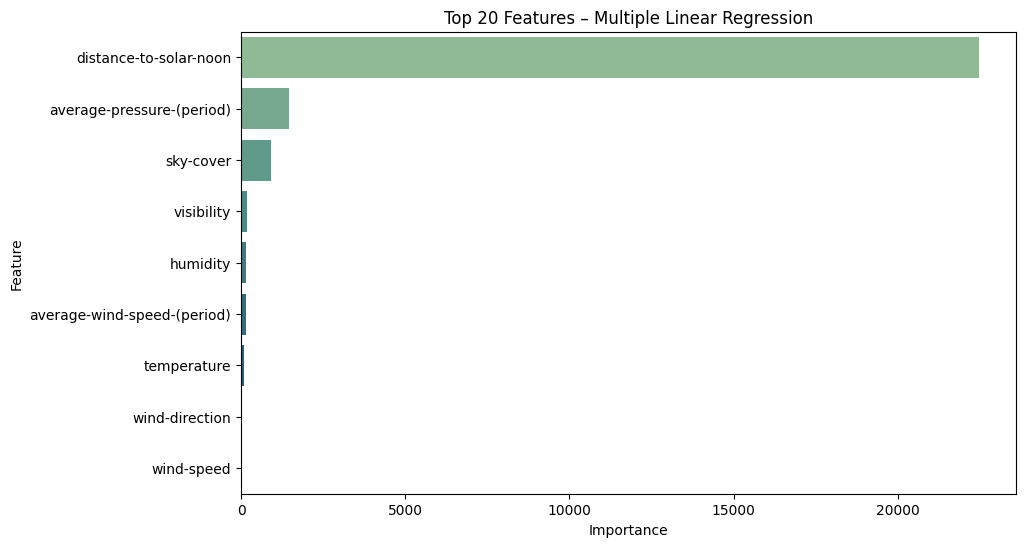

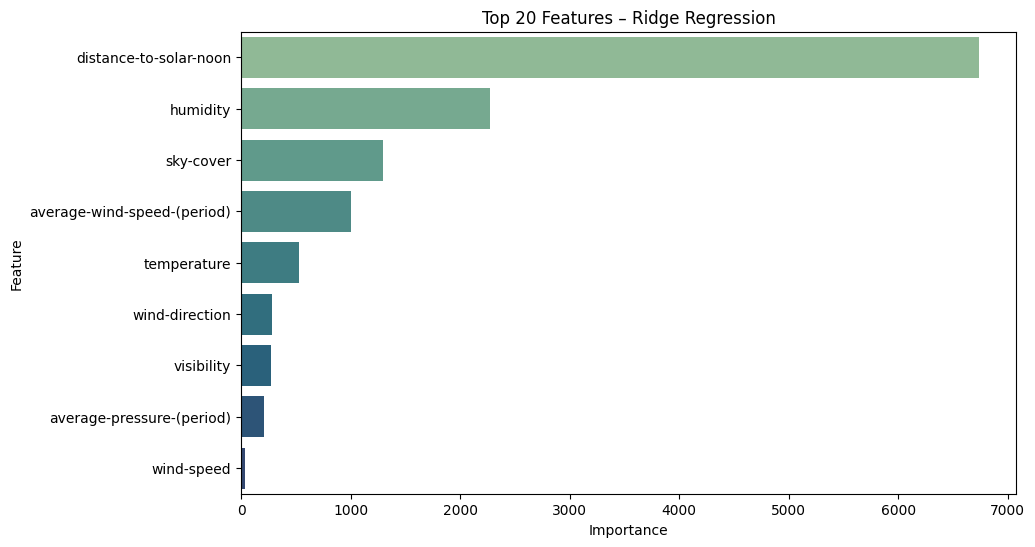

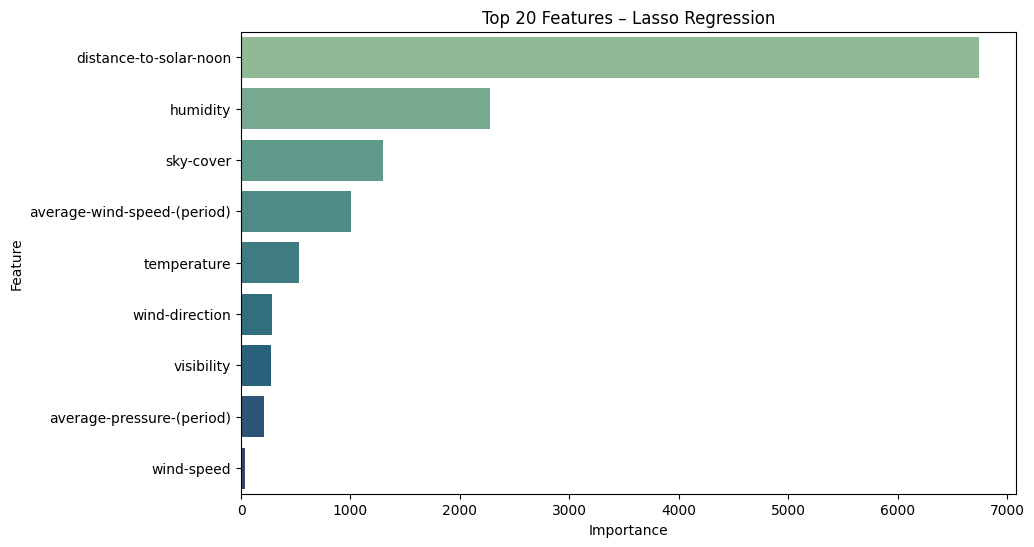

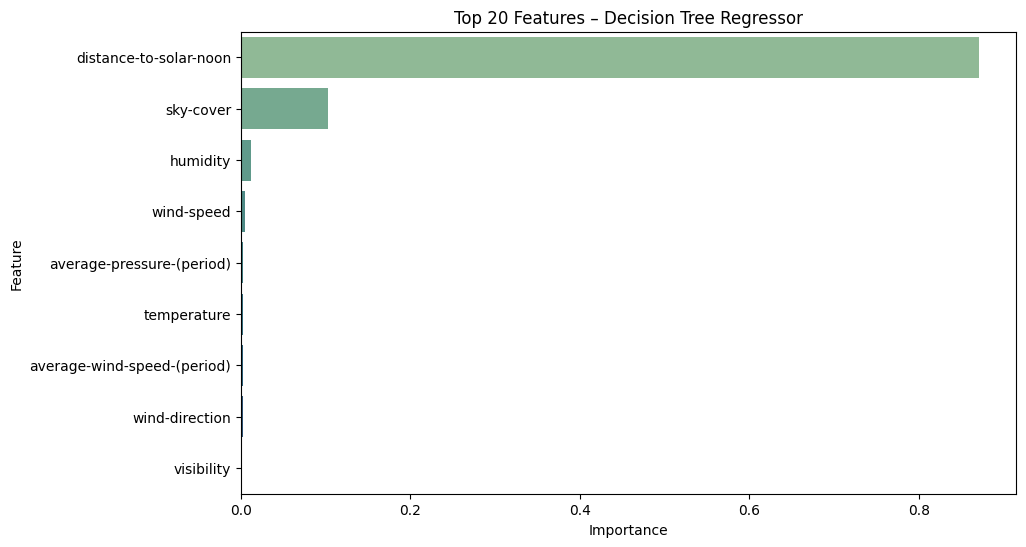

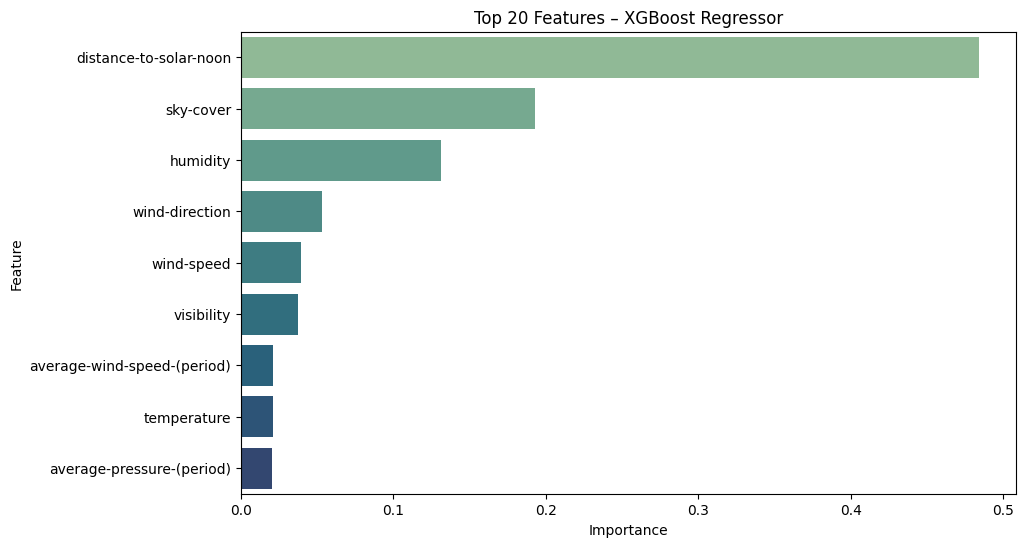

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000132 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 680
[LightGBM] [Info] Number of data points in the train set: 2336, number of used features: 9
[LightGBM] [Info] Start training from score 7003.485445


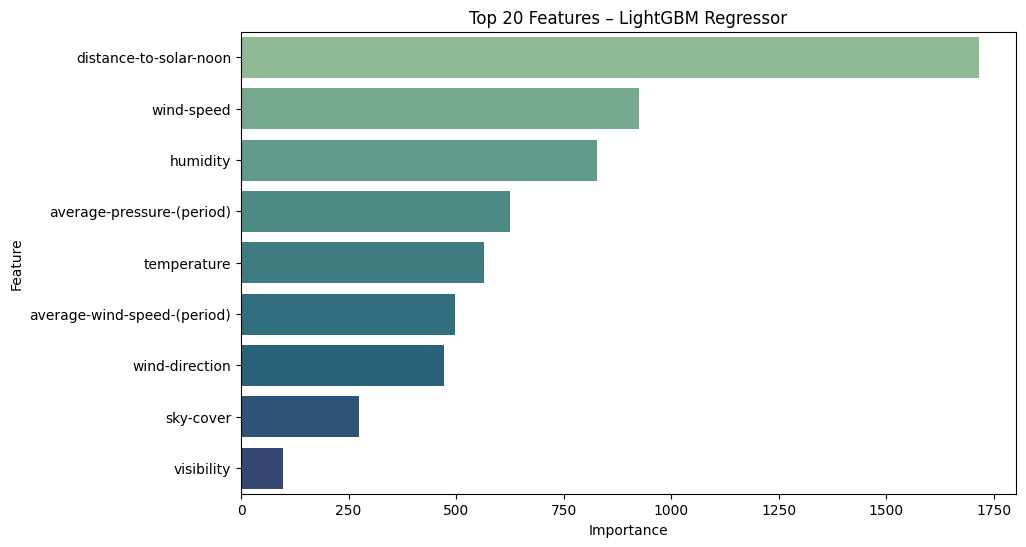

In [17]:
models_with_feature_importances = [
    ("Multiple Linear Regression", LinearRegression()),
    
    ("Ridge Regression", Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0))
    ])),
    
    ("Lasso Regression", Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=0.01, max_iter=5000))
    ])),
    
    ("Decision Tree Regressor", DecisionTreeRegressor(
        max_depth=6, random_state=42
    )),
    
    ("XGBoost Regressor", XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )),
    
    ("LightGBM Regressor", LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ))
]

# --------------------------------------------------
# Iterate over models
# --------------------------------------------------
for model_name, model in models_with_feature_importances:
    
    # Train model
    model.fit(X_train, y_train)
    
    # Extract feature importance
    if hasattr(model, "feature_importances_"):
        feature_importances = model.feature_importances_
    
    elif hasattr(model, "coef_"):
        feature_importances = np.abs(model.coef_)
    
    elif isinstance(model, Pipeline):
        final_model = model.named_steps[list(model.named_steps.keys())[-1]]
        if hasattr(final_model, "coef_"):
            feature_importances = np.abs(final_model.coef_)
        else:
            print(f"{model_name} does not support feature importances.")
            continue
    else:
        print(f"{model_name} does not support feature importances.")
        continue

    # Create DataFrame
    feature_importances_df = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": feature_importances
    }).sort_values(by="Importance", ascending=False)

    # Plot Top 20 Features
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x="Importance",
        y="Feature",
        data=feature_importances_df.head(20),
        palette="crest"
    )
    plt.title(f"Top 20 Features – {model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.grid(False)
    plt.show()


**Model evaluation**

In [33]:
for i, (name, model) in enumerate(models.items(), start=1):

    # Re-fit model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # ===============================
    # Regression Metrics
    # ===============================

    # R2 Score
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # RMSE
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    # MAE
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    # ===============================
    # Results
    # ===============================

    print()
    print(f"Model {i}: {name}")
    print()

    print(f"Training R² Score : {train_r2:.4f}")
    print(f"Testing  R² Score : {test_r2:.4f}")

    print(f"Training MSE     : {train_mse:.4f}")
    print(f"Testing  MSE     : {test_mse:.4f}")

    print(f"Training RMSE    : {train_rmse:.4f}")
    print(f"Testing  RMSE    : {test_rmse:.4f}")

    print(f"Training MAE     : {train_mae:.4f}")
    print(f"Testing  MAE     : {test_mae:.4f}")

    print()
    print("Regression Performance Summary (Test Data):")
    print(f"R² Score : {test_r2:.4f}")
    print(f"MSE      : {test_mse:.4f}")
    print(f"RMSE     : {test_rmse:.4f}")
    print(f"MAE      : {test_mae:.4f}")

    print()
    print("-" * 60)
for i, (name, model) in enumerate(models.items(), start=1):

    # Re-fit model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # ===============================
    # Regression Metrics
    # ===============================

    # R2 Score
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # RMSE
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)

    # MAE
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    # ===============================
    # Results
    # ===============================

    print()
    print(f"Model {i}: {name}")
    print()

    print(f"Training R² Score : {train_r2:.4f}")
    print(f"Testing  R² Score : {test_r2:.4f}")

    print(f"Training MSE     : {train_mse:.4f}")
    print(f"Testing  MSE     : {test_mse:.4f}")

    print(f"Training RMSE    : {train_rmse:.4f}")
    print(f"Testing  RMSE    : {test_rmse:.4f}")

    print(f"Training MAE     : {train_mae:.4f}")
    print(f"Testing  MAE     : {test_mae:.4f}")

    print()
    print("Regression Performance Summary (Test Data):")
    print(f"R² Score : {test_r2:.4f}")
    print(f"MSE      : {test_mse:.4f}")
    print(f"RMSE     : {test_rmse:.4f}")
    print(f"MAE      : {test_mae:.4f}")

    print()
    print("-" * 60)



Model 1: Multiple Linear Regression

Training R² Score : 0.6547
Testing  R² Score : 0.6251
Training MSE     : 36787203.9904
Testing  MSE     : 39494935.3044
Training RMSE    : 6065.2456
Testing  RMSE    : 6284.4996
Training MAE     : 4891.7308
Testing  MAE     : 4981.1543

Regression Performance Summary (Test Data):
R² Score : 0.6251
MSE      : 39494935.3044
RMSE     : 6284.4996
MAE      : 4981.1543

------------------------------------------------------------

Model 2: Ridge Regression

Training R² Score : 0.6547
Testing  R² Score : 0.6248
Training MSE     : 36788556.4606
Testing  MSE     : 39520443.6743
Training RMSE    : 6065.3571
Testing  RMSE    : 6286.5287
Training MAE     : 4888.4163
Testing  MAE     : 4978.7172

Regression Performance Summary (Test Data):
R² Score : 0.6248
MSE      : 39520443.6743
RMSE     : 6286.5287
MAE      : 4978.7172

------------------------------------------------------------

Model 3: Lasso Regression

Training R² Score : 0.6547
Testing  R² Score : 0.6

**Summary Table of Metrics**

In [34]:
summary = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    summary.append({
        "Model": name,
        "R² Score": r2_score(y_test, y_pred),          # accuracy equivalent
        "MSE": mean_squared_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred)
    })

df_summary = pd.DataFrame(summary).sort_values(
    "R² Score", ascending=False
)

df_summary


,Model,R² Score,MSE,RMSE,MAE
4,XGBoost Regressor,0.904558,1.005363e+07,3170.746284,1620.885742
5,LightGBM Regressor,0.891978,1.137871e+07,3373.234591,1624.840881
3,Decision Tree Regression,0.869929,1.370134e+07,3701.532355,1803.719843
0,Multiple Linear Regression,0.625062,3.949494e+07,6284.499607,4981.154256
2,Lasso Regression,0.625061,3.949502e+07,6284.506111,4981.158570
1,Ridge Regression,0.624819,3.952044e+07,6286.528746,4978.717202


**Model Comparison**

In [35]:
comparison_results = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    r2   = r2_score(y_test, y_pred)                      # accuracy equivalent
    mse  = mean_squared_error(y_test, y_pred)            # squared error
    rmse = np.sqrt(mse)                                   # error magnitude
    mae  = mean_absolute_error(y_test, y_pred)           # average error

    comparison_results.append([name, r2, mse, rmse, mae])

comparison_df = pd.DataFrame(
    comparison_results,
    columns=["Model", "R² Score", "MSE", "RMSE", "MAE"]
)

comparison_df


,Model,R² Score,MSE,RMSE,MAE
0,Multiple Linear Regression,0.625062,3.949494e+07,6284.499607,4981.154256
1,Ridge Regression,0.624819,3.952044e+07,6286.528746,4978.717202
2,Lasso Regression,0.625061,3.949502e+07,6284.506111,4981.158570
3,Decision Tree Regression,0.869929,1.370134e+07,3701.532355,1803.719843
4,XGBoost Regressor,0.904558,1.005363e+07,3170.746284,1620.885742
5,LightGBM Regressor,0.891978,1.137871e+07,3373.234591,1624.840881


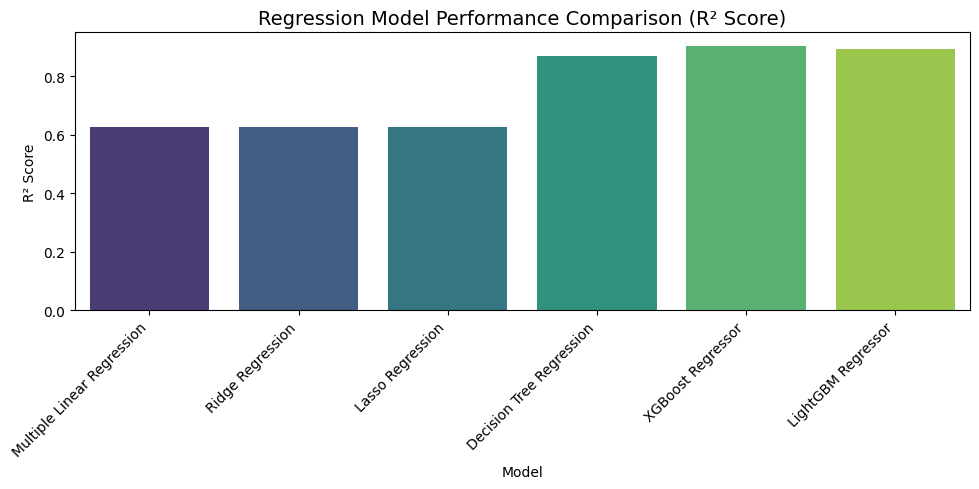

In [36]:
plt.figure(figsize=(10,5))
sns.barplot(
    x="Model",
    y="R² Score",
    data=comparison_df,
    palette="viridis"
)
plt.title("Regression Model Performance Comparison (R² Score)", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Cross-Validation**

In [22]:
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=5,
        scoring="r2"   # regression equivalent of accuracy
    )
    
    cv_results[name] = {
        "Mean CV R²": scores.mean(),
        "Std CV R²": scores.std()
    }

cv_df = pd.DataFrame(cv_results).T
cv_df

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000150 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 670
[LightGBM] [Info] Number of data points in the train set: 2336, number of used features: 9
[LightGBM] [Info] Start training from score 7187.847175
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000149 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 638
[LightGBM] [Info] Number of data points in the train set: 2336, number of used features: 9
[LightGBM] [Info] Start training from score 7783.745291
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000181 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 658
[LightGBM] [Info] Number of data points in the train set: 2336, number of used features: 9
[LightGBM] [Info] Start traini

,Mean CV R²,Std CV R²
Multiple Linear Regression,0.458779,0.329593
Ridge Regression,0.461249,0.323216
Lasso Regression,0.458781,0.329587
Decision Tree Regression,0.785616,0.105251
XGBoost Regressor,0.852976,0.064008
LightGBM Regressor,0.856158,0.049539


**Visualize Model Performance**

In [37]:
r2_list    = []
rmse_list  = []
mse_list   = []
mae_list   = []
model_names = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    model_names.append(name)

    r2_list.append(r2_score(y_test, y_pred))                        # accuracy equivalent
    mse = mean_squared_error(y_test, y_pred)
    mse_list.append(mse)                                            # squared error
    rmse_list.append(np.sqrt(mse))                                  # error magnitude
    mae_list.append(mean_absolute_error(y_test, y_pred))

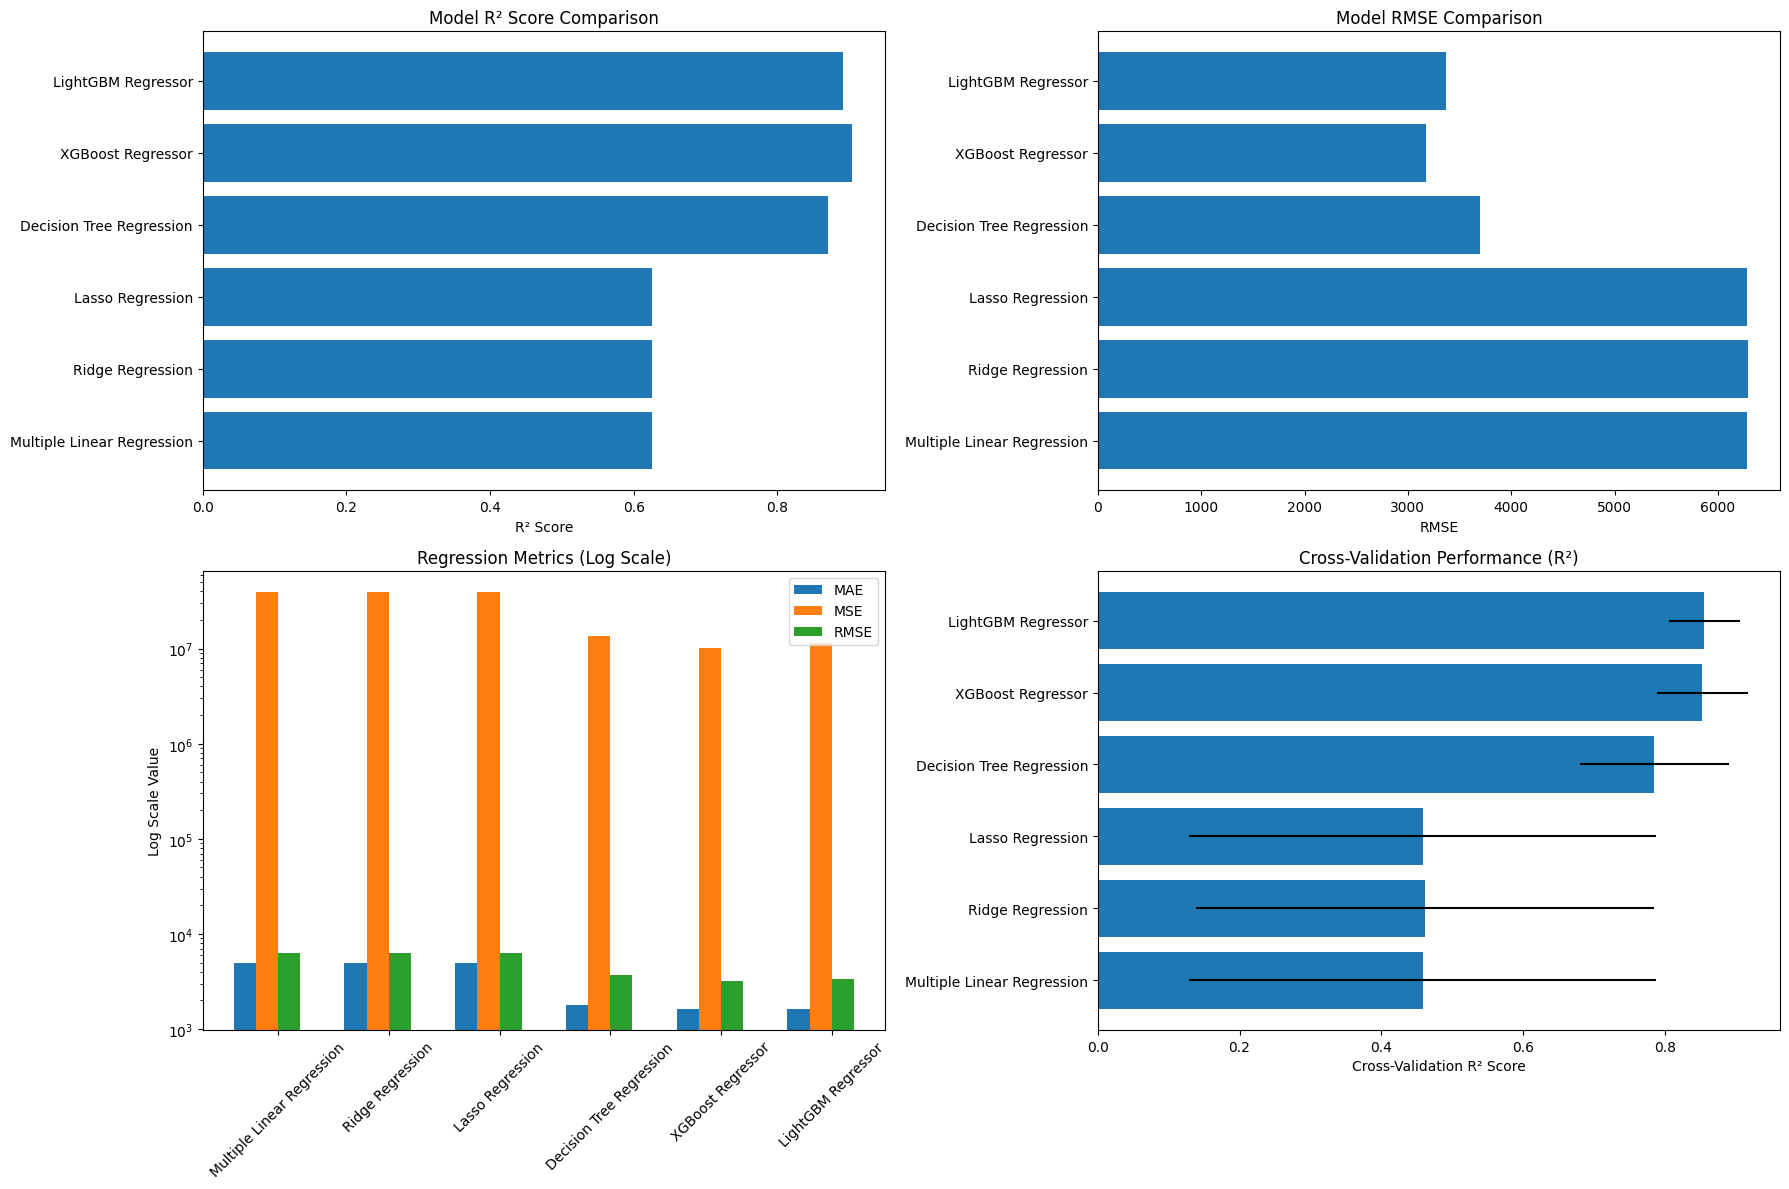

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ---------------------------
# R² Score Comparison
# ---------------------------
axes[0, 0].barh(model_names, r2_list)
axes[0, 0].set_title("Model R² Score Comparison")
axes[0, 0].set_xlabel("R² Score")

# ---------------------------
# RMSE Comparison
# ---------------------------
axes[0, 1].barh(model_names, rmse_list)
axes[0, 1].set_title("Model RMSE Comparison")
axes[0, 1].set_xlabel("RMSE")

# ---------------------------
# All Metrics Comparison
# ---------------------------
x = np.arange(len(model_names))
width = 0.2

axes[1,0].bar(x - width*1.5, mae_list,  width, label="MAE")
axes[1,0].bar(x - width*0.5, mse_list,  width, label="MSE")
axes[1,0].bar(x + width*0.5, rmse_list, width, label="RMSE")

axes[1,0].set_yscale("log")   
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(model_names, rotation=45)
axes[1,0].set_title("Regression Metrics (Log Scale)")
axes[1,0].set_ylabel("Log Scale Value")
axes[1,0].legend()
# ---------------------------
# Cross-Validation Performance
# ---------------------------
cv_means = [cv_df.loc[name]["Mean CV R²"] for name in model_names]
cv_stds  = [cv_df.loc[name]["Std CV R²"] for name in model_names]

axes[1, 1].barh(model_names, cv_means, xerr=cv_stds)
axes[1, 1].set_title("Cross-Validation Performance (R²)")
axes[1, 1].set_xlabel("Cross-Validation R² Score")

plt.tight_layout()
plt.show()

Best Model Selection


Selecting the best model based on Test R² Score...

BEST MODEL SELECTED: XGBoost Regressor

FINAL REGRESSION PERFORMANCE REPORT:
R² Score : 0.9046
MSE      : 10053632.0000
RMSE     : 3170.7463
MAE      : 1620.8857


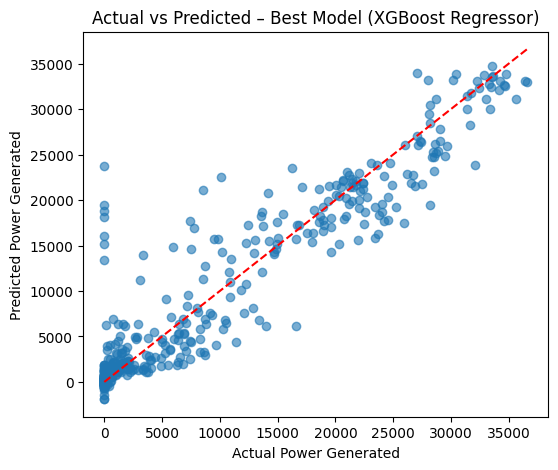

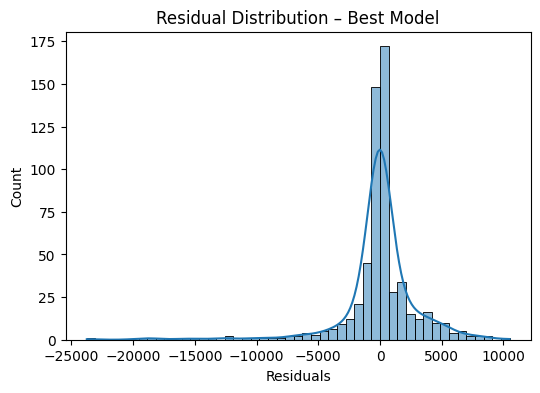


✅ Model saved successfully as best_model.pkl


In [40]:
import joblib

print("\nSelecting the best model based on Test R² Score...\n")

# --------------------------------------------------
# Select Best Model
# --------------------------------------------------
best_model_name = df_summary.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"{'='*80}")
print(f"BEST MODEL SELECTED: {best_model_name}")
print(f"{'='*80}")

# --------------------------------------------------
# Retrain Best Model
# --------------------------------------------------
best_model.fit(X_train, y_train)

# Final predictions
y_pred_final = best_model.predict(X_test)

# --------------------------------------------------
# Final Evaluation Metrics
# --------------------------------------------------
final_r2   = r2_score(y_test, y_pred_final)
final_mse  = mean_squared_error(y_test, y_pred_final)
final_rmse = np.sqrt(final_mse)
final_mae  = mean_absolute_error(y_test, y_pred_final)

print("\nFINAL REGRESSION PERFORMANCE REPORT:")
print(f"R² Score : {final_r2:.4f}")
print(f"MSE      : {final_mse:.4f}")
print(f"RMSE     : {final_rmse:.4f}")
print(f"MAE      : {final_mae:.4f}")

# --------------------------------------------------
# Actual vs Predicted Plot
# (Regression equivalent of confusion matrix)
# --------------------------------------------------
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_final, alpha=0.6)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title(f"Actual vs Predicted – Best Model ({best_model_name})")
plt.xlabel("Actual Power Generated")
plt.ylabel("Predicted Power Generated")
plt.show()

# --------------------------------------------------
# Residual Plot
# --------------------------------------------------
residuals = y_test - y_pred_final

plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution – Best Model")
plt.xlabel("Residuals")
plt.show()

# --------------------------------------------------
# Save Best Model
# --------------------------------------------------
joblib.dump(best_model, "best_model.pkl")

print("\n✅ Model saved successfully as best_model.pkl")


In [41]:
best_model = models[best_model_name]

In [42]:
best_model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [43]:
type(best_model)

xgboost.sklearn.XGBRegressor